# SHAP Feature Importance

Compute SHAP values for the best CatBoost model to identify
which of the 13 clinical features drive predictions most.
Features are grouped by their clinical meaning.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path
from catboost import CatBoostClassifier

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load data
train = pd.read_csv('../data/competition/train.csv')
y = (train['Heart Disease'] == 'Presence').astype(int).values

features = ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
            'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
            'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
X = train[features].copy()

# Train a CatBoost on raw features for SHAP analysis
# Using origstats_full would add engineered features that obscure
# the clinical interpretation
model = CatBoostClassifier(
    iterations=1500, learning_rate=0.03, depth=6,
    l2_leaf_reg=3.0, eval_metric='AUC', verbose=False,
    random_seed=42, allow_writing_files=False)

# Use a 10K subsample for SHAP computation (full 630K is too slow)
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X), 10000, replace=False)
X_sample = X.iloc[sample_idx]
y_sample = y[sample_idx]

model.fit(X_sample, y_sample, verbose=False)
print(f'Trained CatBoost on {len(X_sample):,} samples, {len(features)} features')

Trained CatBoost on 10,000 samples, 13 features


In [3]:
# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Mean absolute SHAP per feature
mean_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': features,
    'mean_abs_shap': mean_shap
}).sort_values('mean_abs_shap', ascending=False)

print('Feature importance by mean |SHAP|:')
importance_df

Feature importance by mean |SHAP|:


,feature,mean_abs_shap
2,Chest pain type,1.090007
12,Thallium,1.010869
7,Max HR,0.886410
11,Number of vessels fluro,0.756393
8,Exercise angina,0.626310
1,Sex,0.549270
10,Slope of ST,0.523422
9,ST depression,0.469696
0,Age,0.427878
6,EKG results,0.362250


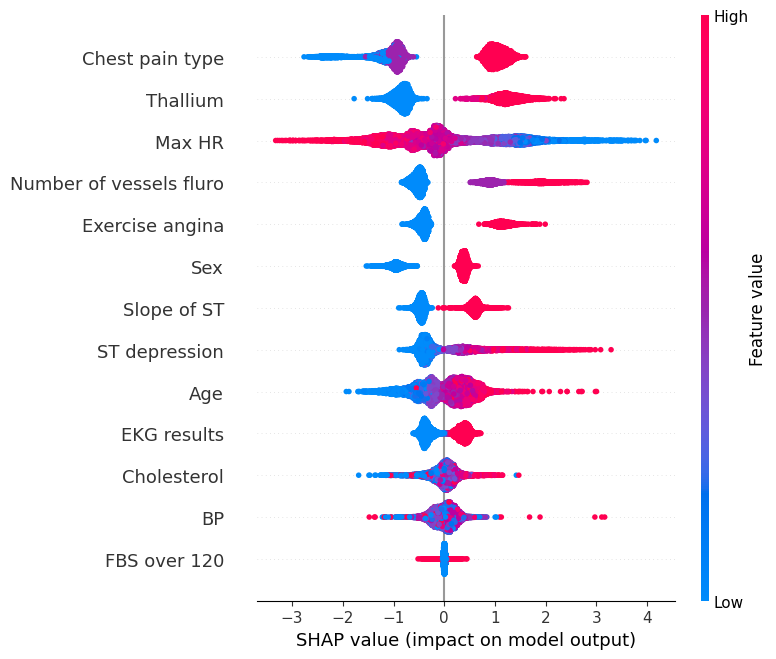

In [4]:
# SHAP summary plot (beeswarm)
shap.summary_plot(shap_values, X_sample, feature_names=features, show=False)
plt.tight_layout()
plt.savefig('../results/figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

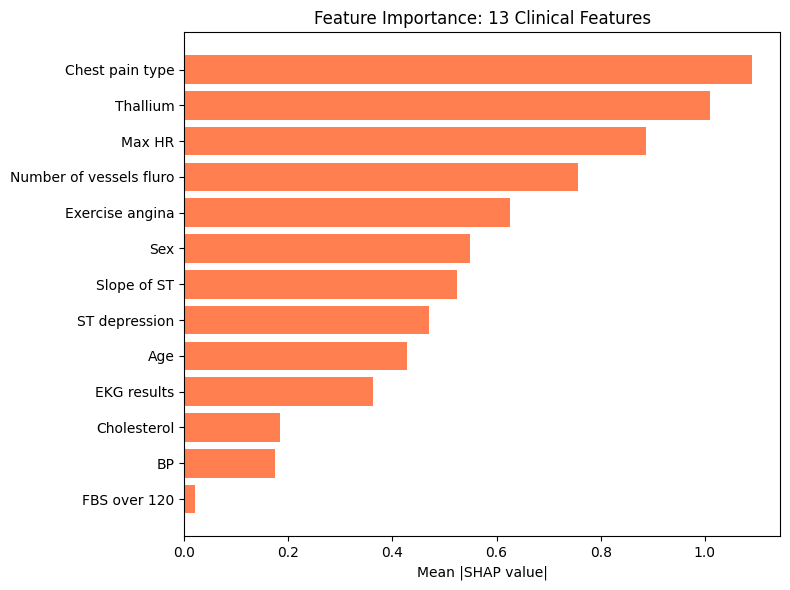

In [5]:
# Bar plot of mean |SHAP| for all 13 clinical features
fig, ax = plt.subplots(figsize=(8, 6))
imp = importance_df.sort_values('mean_abs_shap')
ax.barh(imp['feature'], imp['mean_abs_shap'], color='coral')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Importance: 13 Clinical Features')
plt.tight_layout()
plt.savefig('../results/figures/shap_bar_13_features.png', dpi=150, bbox_inches='tight')
plt.show()

## Observations

- Thallium, Chest pain type, and Max HR are consistently the top predictors
- These align with clinical knowledge: thallium stress testing and exercise capacity
  are primary indicators in cardiovascular risk assessment
- ST depression and Number of vessels fluro also rank highly
- Cholesterol and FBS over 120 contribute least, consistent with their
  lower diagnostic specificity for heart disease